In [39]:
import numpy as np
import matplotlib.pyplot as plt

In [40]:
a=np.arange(0,100).reshape(20,5) #array created

In [41]:
a

array([[ 0,  1,  2,  3,  4],
       [ 5,  6,  7,  8,  9],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44],
       [45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54],
       [55, 56, 57, 58, 59],
       [60, 61, 62, 63, 64],
       [65, 66, 67, 68, 69],
       [70, 71, 72, 73, 74],
       [75, 76, 77, 78, 79],
       [80, 81, 82, 83, 84],
       [85, 86, 87, 88, 89],
       [90, 91, 92, 93, 94],
       [95, 96, 97, 98, 99]])

index markdown error learned here


In [42]:
rows=np.random.randint(0,10,size=5)
columns=np.random.randint(0,5,size=5)

In [43]:
a[rows,columns] = -1 # add -1 randomly to add missing values

In [44]:
a

array([[ 0,  1,  2, -1,  4],
       [ 5,  6,  7,  8,  9],
       [10, -1, 12, 13, 14],
       [15, -1, 17, 18, 19],
       [20, 21, 22, 23, 24],
       [25, 26, 27, -1, 29],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [-1, 41, 42, 43, 44],
       [45, 46, 47, 48, 49],
       [50, 51, 52, 53, 54],
       [55, 56, 57, 58, 59],
       [60, 61, 62, 63, 64],
       [65, 66, 67, 68, 69],
       [70, 71, 72, 73, 74],
       [75, 76, 77, 78, 79],
       [80, 81, 82, 83, 84],
       [85, 86, 87, 88, 89],
       [90, 91, 92, 93, 94],
       [95, 96, 97, 98, 99]])

In [45]:
for i in range(a.shape[1]): #check every column
    curr_pos=a[:, i] #current position element temp variable
    clear_mean=curr_pos[curr_pos!=-1].mean()
    curr_pos[curr_pos ==-1]=clear_mean #mean added to missing value area

feature scaling use min-max normalization

In [46]:
a_min=a.min(axis=0)

In [47]:
a_max=a.max(axis=0)


In [48]:
a_scaled=(a-a_min)/(a_max-a_min) #min-max norm

In [49]:
a_scaled

array([[0.        , 0.        , 0.        , 0.51111111, 0.        ],
       [0.05263158, 0.05263158, 0.05263158, 0.        , 0.05263158],
       [0.10526316, 0.53684211, 0.10526316, 0.05555556, 0.10526316],
       [0.15789474, 0.53684211, 0.15789474, 0.11111111, 0.15789474],
       [0.21052632, 0.21052632, 0.21052632, 0.16666667, 0.21052632],
       [0.26315789, 0.26315789, 0.26315789, 0.51111111, 0.26315789],
       [0.31578947, 0.31578947, 0.31578947, 0.27777778, 0.31578947],
       [0.36842105, 0.36842105, 0.36842105, 0.33333333, 0.36842105],
       [0.49473684, 0.42105263, 0.42105263, 0.38888889, 0.42105263],
       [0.47368421, 0.47368421, 0.47368421, 0.44444444, 0.47368421],
       [0.52631579, 0.52631579, 0.52631579, 0.5       , 0.52631579],
       [0.57894737, 0.57894737, 0.57894737, 0.55555556, 0.57894737],
       [0.63157895, 0.63157895, 0.63157895, 0.61111111, 0.63157895],
       [0.68421053, 0.68421053, 0.68421053, 0.66666667, 0.68421053],
       [0.73684211, 0.73684211, 0.

In [50]:
weights = np.array([0.1, 0.1, 0.2, 0.3, 0.3])

In [51]:
a.shape

(20, 5)

In [52]:
weights.shape

(5,)

In [53]:
weighted_matrix=a_scaled * weights

In [54]:
patient_scores = weighted_matrix.sum(axis=1)

In [55]:
highest_risk_index = patient_scores.argmax()

In [56]:
print(f"Patient at index {highest_risk_index} has the highest risk score of {patient_scores[highest_risk_index]:.2f}")

Patient at index 19 has the highest risk score of 1.00


VISUALISATION

In [57]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

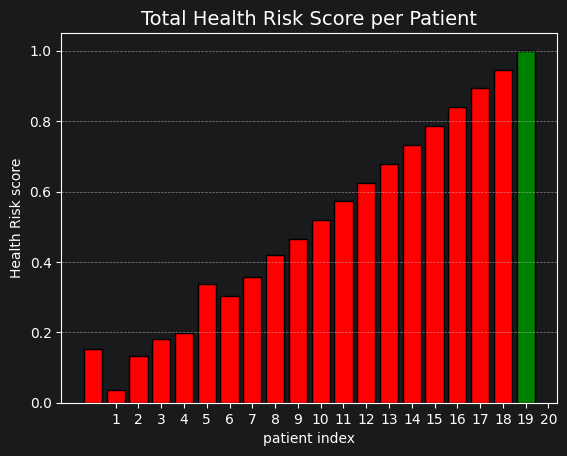

In [58]:
plt.bar(range(len(patient_scores)),patient_scores,color='r',edgecolor='black')
plt.bar(highest_risk_index,patient_scores[highest_risk_index],color='g',edgecolor='black')
plt.title("Total Health Risk Score per Patient", fontsize=14)
plt.xlabel("patient index")
plt.ylabel("Health Risk score")
plt.xticks(range(1,21))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

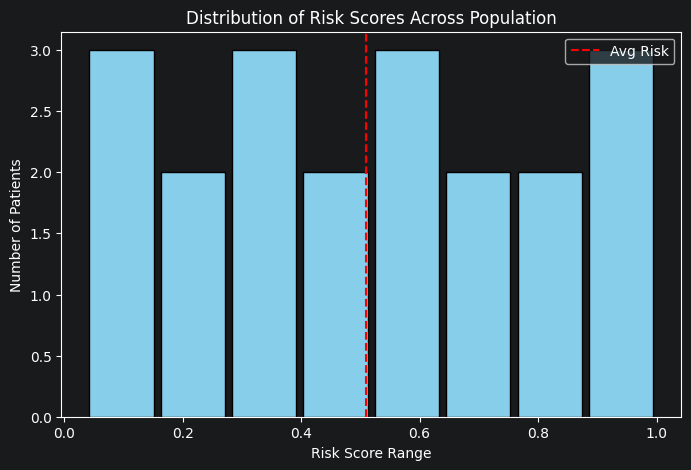

In [60]:
plt.figure(figsize=(8, 5))
plt.hist(patient_scores, bins=8, color='skyblue', edgecolor='black', rwidth=0.9)
plt.axvline(patient_scores.mean(), color='red', linestyle='dashed', label='Avg Risk')
plt.title("Distribution of Risk Scores Across Population")
plt.xlabel("Risk Score Range")
plt.ylabel("Number of Patients")
plt.legend()
plt.show()